In [319]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential
from datetime import datetime

Fetching the data

In [320]:
end = datetime.now().date()
start = datetime(end.year - 8, end.month, end.day)
stock = 'SBIN.NS'

df = yf.download(stock, start, end)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
Date,,,,,
2018-06-25,243.317490,247.577455,242.184516,246.399173,10934401
2018-06-26,242.365768,245.810026,240.553010,242.229817,16867009
2018-06-27,237.199417,242.320453,236.564941,242.320453,16277655
2018-06-28,232.939407,237.471302,231.761112,236.021090,21349738
2018-06-29,235.069412,238.785572,234.027082,234.072390,16244724


In [321]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
0,2018-06-25,243.317490,247.577455,242.184516,246.399173,10934401
1,2018-06-26,242.365768,245.810026,240.553010,242.229817,16867009
2,2018-06-27,237.199417,242.320453,236.564941,242.320453,16277655
3,2018-06-28,232.939407,237.471302,231.761112,236.021090,21349738
4,2018-06-29,235.069412,238.785572,234.027082,234.072390,16244724


In [322]:
df = df.drop(['Date'], axis=1)
df.head()

/tmp/ipykernel_15444/2218488136.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date'], axis=1)


Price,Close,High,Low,Open,Volume
Ticker,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
0,243.317490,247.577455,242.184516,246.399173,10934401
1,242.365768,245.810026,240.553010,242.229817,16867009
2,237.199417,242.320453,236.564941,242.320453,16277655
3,232.939407,237.471302,231.761112,236.021090,21349738
4,235.069412,238.785572,234.027082,234.072390,16244724


Observing the close price trend

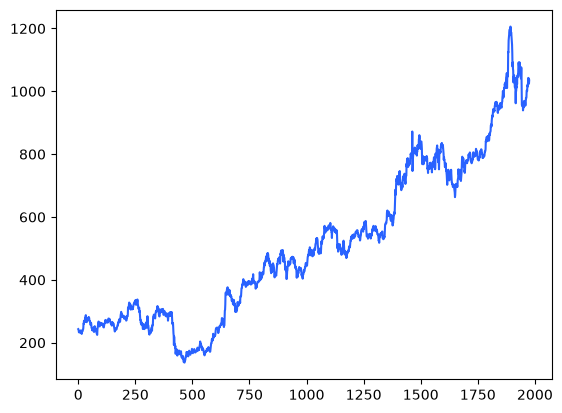

In [323]:
plt.plot(df.Close, color='#2962ff')

Calculating and observing moving average 100

In [324]:
ma100 = df.Close.rolling(window=100).mean()
ma100

Ticker,SBIN.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1971,1049.383090
1972,1049.436210
1973,1049.730992
1974,1049.627961


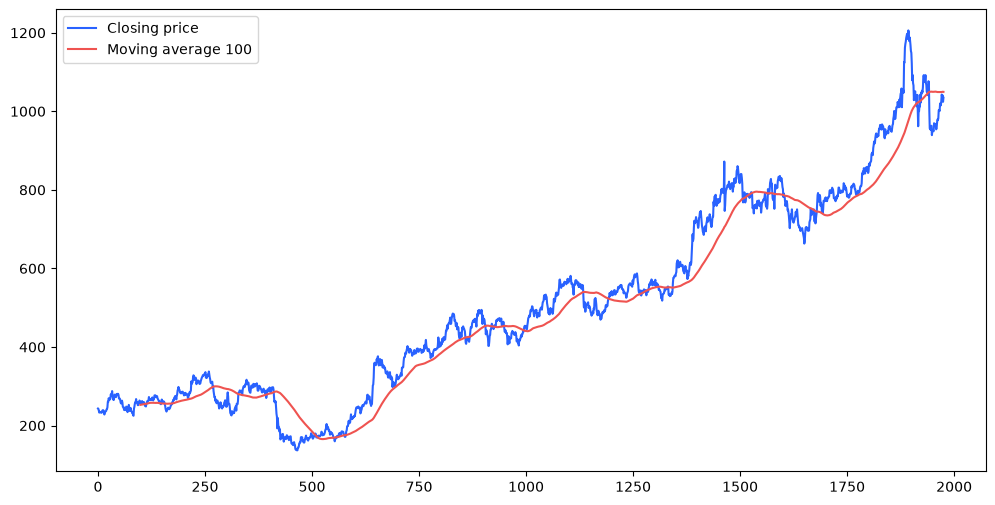

In [325]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, color='#2962ff', label='Closing price')
plt.plot(ma100, color='#ef5350', label='Moving average 100')
plt.legend()

Calculating and observing moving average 200

In [326]:
ma200 = df.Close.rolling(window=200).mean()
ma200

Ticker,SBIN.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1971,981.030748
1972,982.264792
1973,983.509652
1974,984.682320


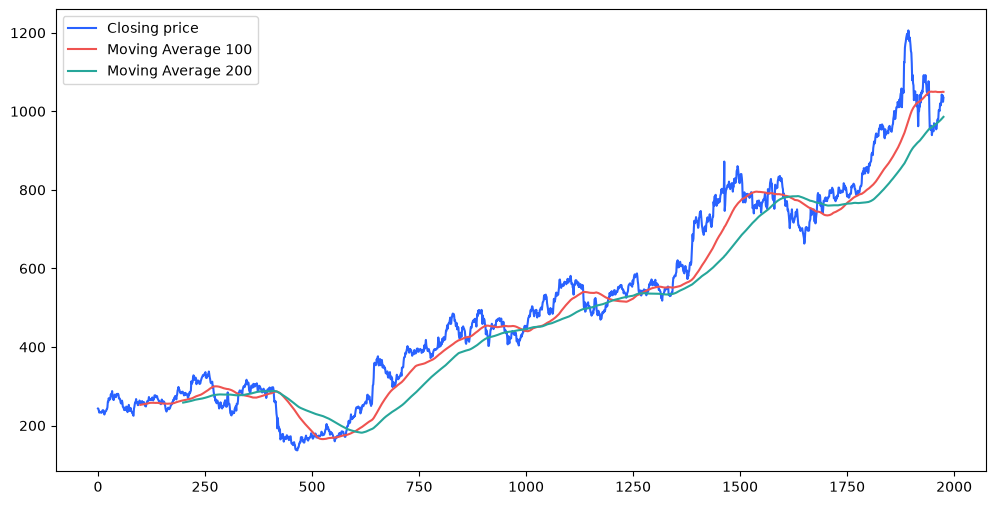

In [327]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, color='#2962ff', label="Closing price")
plt.plot(ma100, color='#ef5350', label='Moving Average 100')
plt.plot(ma200, color='#26a69a', label='Moving Average 200')
plt.legend()

In [328]:
df.shape

(1976, 5)

Splitting data into training and testing data

In [329]:
data_training = pd.DataFrame(df['Close'][0: int(len(df) * 0.80)])
data_testing = pd.DataFrame(df['Close'][int(len(df) * 0.80): int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(1580, 1)
(396, 1)


In [330]:
data_training.head()

Ticker,SBIN.NS
0,243.317490
1,242.365768
2,237.199417
3,232.939407
4,235.069412


In [331]:
data_testing.head()

Ticker,SBIN.NS
1580,751.829712
1581,785.822144
1582,813.170105
1583,808.307251
1584,803.203491


Scailing the data

In [332]:
scaler = MinMaxScaler(feature_range=(0, 1))

data_training_array_scale = scaler.fit_transform(data_training)

In [333]:
x_train = []
y_train = []

for i in range(100, data_training_array_scale.shape[0]):
    x_train.append(data_training_array_scale[i-100: i])
    y_train.append(data_training_array_scale[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

Setting up the model

In [334]:
model = Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True,))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

/home/subhadip/Desktop/Stock-Price-Predtiction-Model/venv/lib/python3.14/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [335]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [336]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 0.0422
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - loss: 0.0106
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 217ms/step - loss: 0.0074
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.0071
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0072
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0065
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 0.0057
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 0.0058
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 0.0058
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0057
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 0.0052
Epoch 12/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.0054
Epoch 13/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0055
Epoch 14/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - loss: 0.0048
Epoch 15/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - l

Saving the model

In [337]:
model.save('../model/keras_stock_predictor_model.h5')

Testing the model

In [338]:
past_100_days = data_training.tail(100)

In [339]:
final_data = pd.concat([past_100_days, data_testing], ignore_index=True)

final_data

Ticker,SBIN.NS
0,812.736755
1,817.503479
2,810.762756
3,795.548035
4,808.836853
...,...
491,1042.699951
492,1035.099976
493,1040.750000
494,1024.199951


In [340]:
input_data = scaler.fit_transform(final_data)

In [341]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

Predictions with the model

In [342]:
y_predict = model.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [343]:
close_data = df[['Close']].values
scale_data = scaler.fit_transform(close_data)
scaler.scale_

array([0.00093516])

In [344]:
scale_factor = 1 / 0.00355286
y_predict = y_predict * scale_factor
y_test = y_test * scale_factor

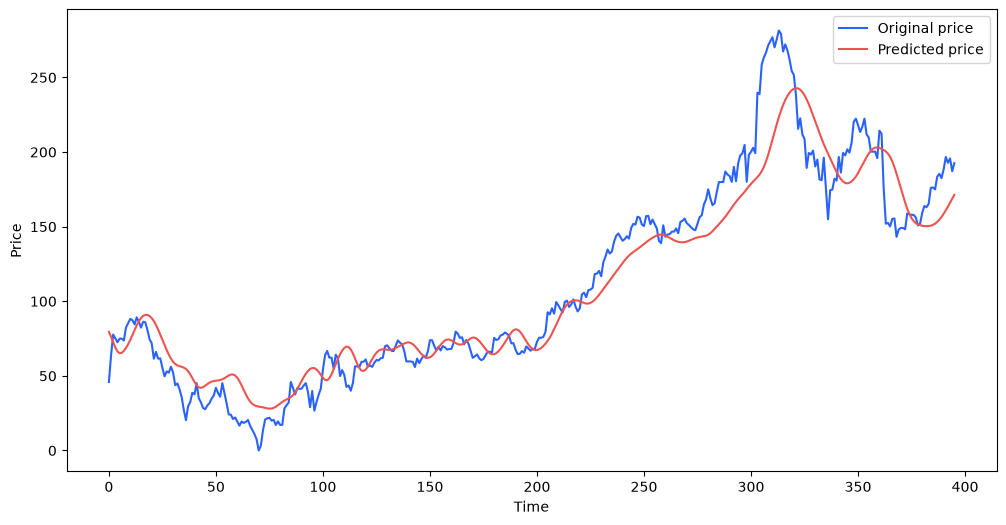

In [345]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, color='#2962ff', label='Original price')
plt.plot(y_predict, color='#ef5350', label='Predicted price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()